# Exploratory Data Analysis:

Before any modeling, we need to understand carefully our data. That is why we nned to answer questions based on our eyes and our own numbers.

In [18]:
import os
from collections import Counter
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import wfdb
import json

REPO_ROOT = Path.cwd()
if not (REPO_ROOT/"data").exists() and (REPO_ROOT.parent/"data").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT/"data"/"raw"
FIG_DIR = REPO_ROOT/"results"/"figures"
FIG_DIR.mkdir(parents=True,exist_ok=True)

assert DATA_DIR.exists(), f"{DATA_DIR} not found run download_mitbih() first."



Each MIT-BIH is stored as three files sharing a name: .hea (header), .dat (signal), .atr (annotations). We build the list of record names by scanning the .hea files on disk rather than hard-coding it, so that if the download is incomplete the count immediately reveals it.

In [19]:
RECORDS = sorted(p.stem for p in DATA_DIR.glob("*hea"))
print(f"{len(RECORDS)} records found: {RECORDS}")

48 records found: ['100', '101', '102', '103', '104', '105', '106', '107', '108', '109', '111', '112', '113', '114', '115', '116', '117', '118', '119', '121', '122', '123', '124', '200', '201', '202', '203', '205', '207', '208', '209', '210', '212', '213', '214', '215', '217', '219', '220', '221', '222', '223', '228', '230', '231', '232', '233', '234']


## 1 - Physical structure of one record

We start with record 100 and inspect everything the header gives us before plotting a single point.

In [20]:
record = wfdb.rdrecord(str(DATA_DIR/"100"))
print(f"record name: {record.record_name}")
print(f"sampling frequency: {record.fs} Hz")
print(f"number of leads: {record.n_sig}")
print(f"lead names: {record.sig_name}")
print(f"units: {record.units}")
print(f"signal length: {record.sig_len} samples")
print(f"duration: {record.sig_len/record.fs/60:.2f} minutes")
print(f"signal array shape: {record.p_signal.shape} (samples,leads)")
print(f"dtype: {record.p_signal.dtype}")
print(f"ADC resolution: {record.adc_res} bits")
print(f"NaNs present: {np.isnan(record.p_signal).any()}")

record name: 100
sampling frequency: 360 Hz
number of leads: 2
lead names: ['MLII', 'V5']
units: ['mV', 'mV']
signal length: 650000 samples
duration: 30.09 minutes
signal array shape: (650000, 2) (samples,leads)
dtype: float64
ADC resolution: [11, 11] bits
NaNs present: False


Record 100 is sampled at 360 Hz on 2 leads (MLII and V5), measured in millivolts and lasts about 30 minutes (650000 samples per lead). The signal has no missing values, so no gap-filling is needed before analysis.

Every conversion from sample number to seconds divides by 360. This is the most commun mistake in the dataset, so we fix the value once and reuse it.

We work on lead MLII (Modified Limb Lead II), the standard lead where the heartbeat spike is most prominent and easiest to detect. We select by name because a few records do not contain MLII and selecting by position would silently give us a different lead.

## 2 - Annotation format

"wfdb.rdann" returns an object whose two fields matter to us:

|   field   |   type  | meaning  |
|-----------|---------|----------|
| annotation.sample | int64 array | sample index of the annotation (an integer offset into p_signal, not seconds) |
| annotation.symbol | list of str | one character describing the event at that sample |

The sample index is placed on the R-peak (the tall spike). 

In [21]:
annotation = wfdb.rdann(str(DATA_DIR/"100"),"atr")

print(f"number of annotations: {len(annotation.sample)}")
print(f"sample dtype: {annotation.sample.dtype}")
print(f"first 10 samples: {annotation.sample[:10]}")
print(f"first 10 symbols: {annotation.sample[:10]}")



number of annotations: 2274
sample dtype: int64
first 10 samples: [  18   77  370  662  946 1231 1515 1809 2044 2402]
first 10 symbols: [  18   77  370  662  946 1231 1515 1809 2044 2402]


In [22]:
df_ann = pd.DataFrame({ "sample": annotation.sample,
                        "time_s": annotation.sample/record.fs,
                        "symbol": annotation.symbol})
df_ann.head(10)

,sample,time_s,symbol
0,18,0.050000,+
1,77,0.213889,N
2,370,1.027778,N
3,662,1.838889,N
4,946,2.627778,N
5,1231,3.419444,N
6,1515,4.208333,N
7,1809,5.025000,N
8,2044,5.677778,A
9,2402,6.672222,N


The atr file does not only mark heartbeats. Cardiologists also recorded other events in it: (+) a rythm change, (~) a stretch of poor signal quality, (") a lead switch, (|) an isolated artifact. These have a sample position exactly like a beat does but no heartbeat occurs there. This matters because our whole approach is to cut a window around each annotation. If we cut a window around (~) we hand the model pure noise and label it as a beat. We need to keep the symbols that mark a real beat and drop the rest.

Ours second problem is that MIT-BIH distinguishes 16 beats types but some appear only a couple of times in the entire database. Training on 16 classes is not realistic. The AAMI EC57 (Association for the Advancement of Medical Instrumentation) is the medical device standard that defines how heartbeat classification algorithms are evaluated. It groups the many MIT-BIH beat types into 5 classes, which is the grouping every published study reports on. These 5 classes are:

| class | meaning |
|-------|---------|
| N | normal beat |
| S | supraventricular ectopic: abnormal beat originating in the upper chambers|
| V | vebtricular ectopic: abnormal beat originating in the lower chambers |
| F | fusion: a normal and a ventricular beat overlapping, so the shape mixes both |
| Q | unknown, paced or unclassifiable |



In [23]:
SYMBOLS = set("NLRejAaJSVEFP/fQ")

AAMI_MAP = {# N: normal heart beat
            "N": "N", "L": "N","R":"N","e":"N","j":"N",
            # S: supraventicular ectopic
            "A":"S","a":"S","J":"S", "S":"S",
            # V: ventricular ectopic
            "V":"V", "E":"V",
            # F: fusion
            "F":"F",
            # Q: unknown/paced/ unclassifiable
            "/":"Q", "f":"Q","Q":"Q", "P":"Q"
}
AAMI_CLASSES = ["N","S","V","F","Q"]


raw_counts = Counter(annotation.symbol)
print("Record 100:")
for sym, n in raw_counts.most_common():
    kind = "beat" if sym in SYMBOLS else "NON-BEAT"
    print(f"{sym!r:5} {n:6d} {kind}")


Record 100:
'N'     2239 beat
'A'       33 beat
'+'        1 NON-BEAT
'V'        1 beat


## 3 - Look at the raw signal next to its annotations

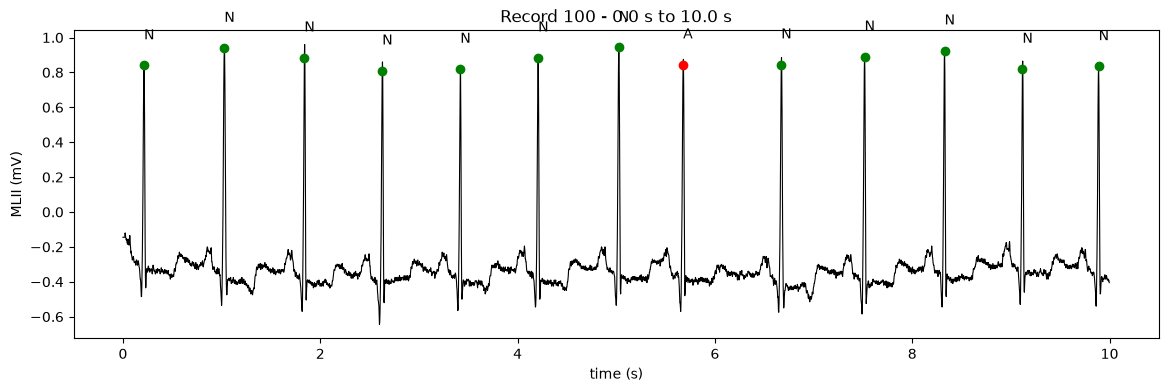

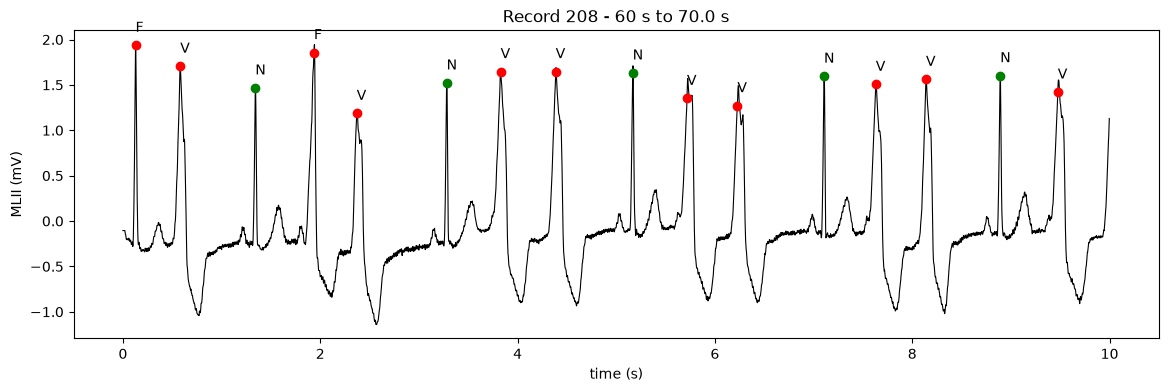

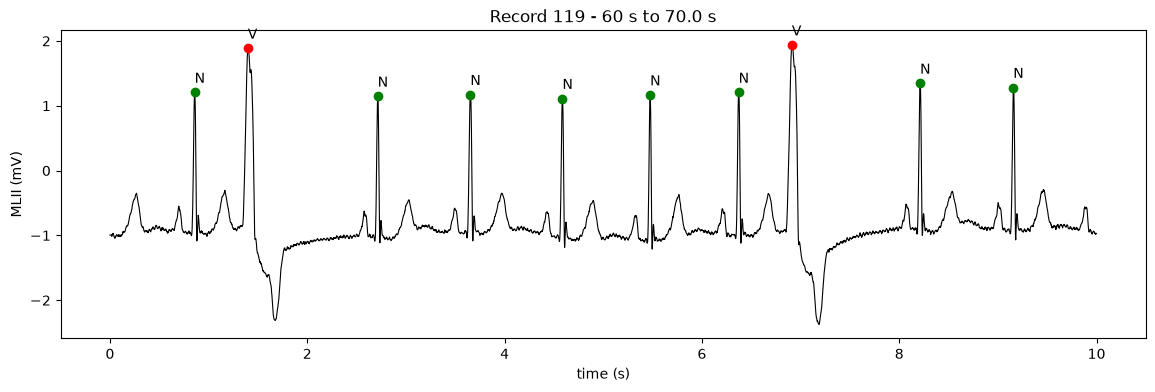

In [24]:
def plot_beats(name, start_s=0.0, dur_s=10.0):
    rec = wfdb.rdrecord(str(DATA_DIR/name))
    ann = wfdb.rdann(str(DATA_DIR/name),'atr')
    lead = rec.sig_name.index("MLII")

    i0, i1 = 0, 10*360
    mask = (ann.sample >=i0) & (ann.sample <i1)
    plt.figure(figsize=(14,4))
    plt.plot(np.arange(i0,i1)/360, rec.p_signal[i0:i1, lead], "k",lw=0.8)
    for s, sym in zip(ann.sample[mask], np.array(ann.symbol)[mask]):
        if sym not in SYMBOLS:
            continue
        cls = AAMI_MAP[sym]
        color = "green" if cls =="N" else "red"
        plt.scatter(s/360, rec.p_signal[s,lead], color = color , zorder=3)
        plt.text(s/360, rec.p_signal[s,lead] +0.15,sym)
        plt.savefig(FIG_DIR/f"record{name}_annotated.png")
        
    plt.xlabel("time (s)")
    plt.ylabel("MLII (mV)")
    plt.title(f"Record {name} - {start_s} s to {start_s + dur_s} s")

plot_beats('100')
plot_beats('208',start_s=60)
plot_beats('119',start_s=60)

In all three records the markers land exactly on top of the peaks, never in the flat segments between beats. This confirms what we said before in the second section (annotation.sample is a row index into p_signal and it's placed on the R-peak). Our sample to second conversion is correct (sample/360).

Record 100 is a baseline of normality. Over 10 seconds we see 12 beats, regularly spaced each 0.8 seconds, all labelled "N" except a single "A" (supraventricular). The "A" beat looks identical in shape to it's neighbours (the anomaly is in the timing). This is a warning for the modelling phase because a model that only sees the beat's shape with no information about the interval preceding it, cannot detect this class.

Record 208 shows what a ventricular anomaly looks like. The "V" beats are visually obvious and differ from "N".

Record 119 have regular "N" beats that are interrupted by two isolated "V" beats that are unmistakable. This is the classic pattern our detection should catch first.

## 4 - Normal VS Anomalous

We extract fixed-length windows centred on the R-peak and overlay many beats of the same class. This shows what a model actually has to discriminate.

We chose a window: 250 ms before the peak and 400 ms after. This window will help us capture P wave, QRS and T wave.

In [25]:
PRE= int(0.25 * 360) # 90 samples
POST = int(0.40*360)  # 144 samples

def extract_beats(record_name, lead =0):
    rec = wfdb.rdrecord(str(DATA_DIR/record_name))
    ann = wfdb.rdann(str(DATA_DIR/record_name), "atr")

    beats, labels = [],[]
    for s, sym in zip(ann.sample, ann.symbol):
        
        if sym not in SYMBOLS:
            continue
        if s-PRE <0 or s+POST >rec.sig_len:
            continue
        beats.append(rec.p_signal[s-PRE :  s+ POST, lead])
        labels.append(AAMI_MAP[sym])
    
    return np.asarray(beats), np.asarray(labels)

x208, y208 = extract_beats("208")
print("beat matrix: ",x208.shape)
print("classes present: ", Counter(y208))

beat matrix:  (2953, 234)
classes present:  Counter({np.str_('N'): 1585, np.str_('V'): 992, np.str_('F'): 372, np.str_('S'): 2, np.str_('Q'): 2})


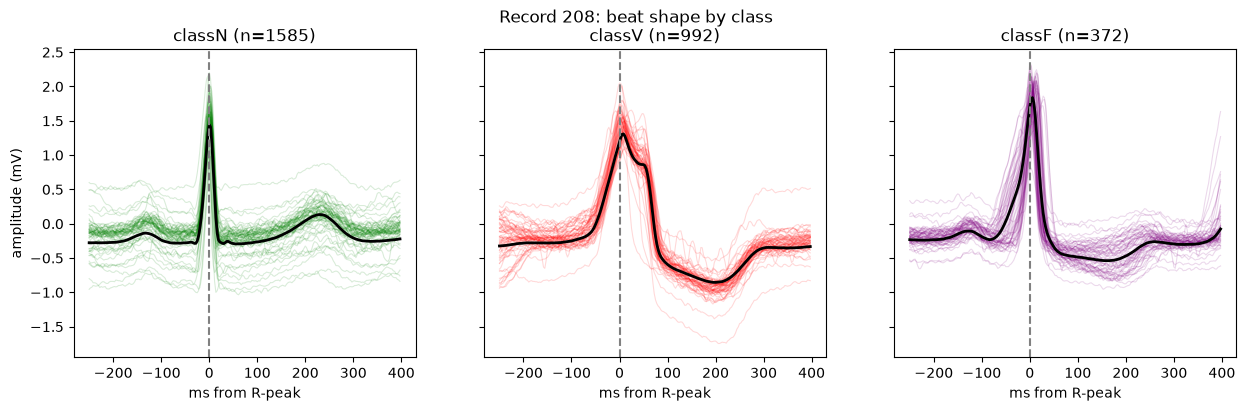

In [26]:
fig, axes = plt.subplots(1,3,figsize=(15,4),sharey=True)
t_ms = (np.arange(x208.shape[1])- PRE)/360*1000 # ms, R peak at 0

for ax, cls, color in zip(axes, ["N","V","F"],["green","red","purple"]):
    beats = x208[y208==cls]
    ax.plot(t_ms,beats[:60].T, color=color, alpha=0.15, lw=0.8) # 60 beats
    ax.plot(t_ms,beats.mean(0),color = "black",lw=2)
    ax.axvline(0,ls="--",c="gray")
    ax.set_title(f"class{cls} (n={len(beats)})")
    ax.set_xlabel("ms from R-peak")


axes[0].set_ylabel("amplitude (mV)")
plt.suptitle("Record 208: beat shape by class")

plt.savefig(FIG_DIR/"beat_morphology.png")
    

The three classes have different shapes. "N" has a sharp R-peak, followed by a small rounded bump. "V" has a wider R-peak and the beat is followed by a deep dip below baseline that the normal beats don't have. "F" sits between "N" and "V" which matches its definition. 

## 5 - Class distribution across the whole database

One record can't tell us if we have an imbalanced class that is why we need to look at the 48 records.

In [27]:
# for every record we coount how many beats of each AAMI class it contains.
rows = []
for name in RECORDS:
    ann = wfdb.rdann(str(DATA_DIR/name), "atr")
    header = wfdb.rdheader(str(DATA_DIR/name))
    beat_classes = [] # keep only real beats
    for symbol in ann.symbol:
        if symbol in SYMBOLS:
            beat_classes.append(AAMI_MAP[symbol])
    
    class_counts = Counter(beat_classes)
    row = {"record": name,
           "leads": "/".join(header.sig_name),
           "n_beats": len(beat_classes),
           "N": class_counts.get("N",0),
           "S": class_counts.get("S", 0),
           "V": class_counts.get("V",0),
           "F": class_counts.get("F",0),
           "Q":class_counts.get("Q",0)
           }
    rows.append(row)

summary = pd.DataFrame(rows)
summary.head()

,record,leads,n_beats,N,S,V,F,Q
0,100,MLII/V5,2273,2239,33,1,0,0
1,101,MLII/V1,1865,1860,3,0,0,2
2,102,V5/V2,2187,99,0,4,0,2084
3,103,MLII/V2,2084,2082,2,0,0,0
4,104,V5/V2,2229,163,0,2,0,2064


In [28]:
totals = summary[["N","S","V","F","Q"]].sum()
total_beats = totals.sum()
print('Total beats:' ,total_beats)

for cls in ["N","S","V","F","Q"]:
    count = totals[cls]
    percent = 100*count/total_beats
    print(f"{cls}: {count>6} ({percent:.1f}%)")
print(f"\n There are {totals['N'] /totals['F']} normal beats for every fusion beat.")

Total beats: 109494
N: True (82.8%)
S: True (2.5%)
V: True (6.6%)
F: True (0.7%)
Q: True (7.3%)

 There are 112.86550435865504 normal beats for every fusion beat.


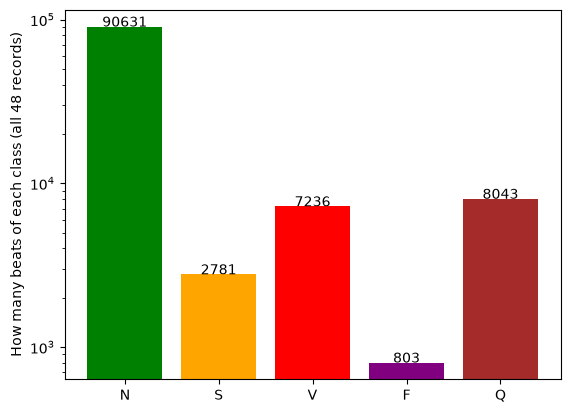

In [29]:
plt.figure()
plt.bar(["N","S","V","F","Q"],totals, color = ["green","orange","red","purple","brown"])
plt.yscale("log") # N is bigger than the other that is why we use log as a scale
plt.ylabel("How many beats of each class (all 48 records)")

for i, count in enumerate(totals):
    plt.text(i,count,str(count),ha="center")

plt.savefig(FIG_DIR/"class_distribution.png")

Across all the 48 records there are 90631 normal beats but only 803 fusion beats. Class N alone makes up to 85% of all beats. This tells us that we have a strong class imbalance.

## 6 - Pitfalls found in the data

In [30]:
no_mlii = [name for name in RECORDS if "MLII" not in wfdb.rdheader(str(DATA_DIR/name)).sig_name]
print("records without MLII: ",no_mlii)

records without MLII:  ['102', '104']


Most records use MLII, but records 102 and 104 don't have it. So we select the lead by its name and not its position, otherwise these two would sneak a different signal into the data.

In [31]:
paced_records = []
for name in RECORDS:
    ann = wfdb.rdann(str(DATA_DIR/name), "atr")
    if "/" in ann.symbol:
        paced_records.append(name)
print("records with paced beats:", paced_records)

records with paced beats: ['102', '104', '107', '217']


Paced beats are the patients wih a pacemaker. They are marked with the symbol "/". The AAMI standard excludes these records because their artificial beats are too easy to classify and would inflate our results.

Later we will train a model on some beats and test it on others. The obvious way to split the data between train and test is a trap because the same patient's beats would land in both the training and test sets. The model would memorise that patient's heartbeat shape and score perfectly but it would fail on new patients. This is called data leakage. The fix is to split by patient not by beat, all of one patient's beats go entirely to testing. We use the split from "De chazal et al. (2004)" which is what most published work on MIT-BIH uses so our results stay comparable. It will leave the four paced records.

In [32]:
DS1_train = ["101", "106", "108", "109", "112","114", "115", "116", "118", "119", "122",
             "124", "201", "203", "205", "207", "208", "209", "215", "220", "223", "230"]
DS2_test = ["100", "103", "105", "111", "113", "117", "121", "123", "200", "202", "210", 
            "212", "213", "214", "219", "221", "222", "228", "231", "232", "233", "234"] 

In [33]:
assert not set(DS1_train) & set(DS2_test), " a record is in both sets!"
assert not (set(DS1_train) | set(DS2_test)) & set(paced_records), "a paced record leaked in!"
print(f"Train: {len(DS1_train)} records, Test: {len(DS2_test)} records")

Train: 22 records, Test: 22 records


The split gives 22 training and 22 test records, with no paced record included in both and no record where we don't have the label "MLII". 

## 7 - Saving the results



In [34]:
for f in os.listdir(FIG_DIR):
    print(f,os.path.getsize(FIG_DIR/f))

class_distribution.png 19049
record119_annotated.png 42702
record208_annotated.png 59012
record100_annotated.png 51674
beat_morphology.png 197328


In [38]:
RESULTS = REPO_ROOT/"results"
RESULTS.mkdir(exist_ok=True)
summary.to_csv(RESULTS/"record_summary.csv", index=False)
print("saved summary")

totals = summary[["N","S","V","F","Q"]].sum()
stats = {
    "dataset": "MIT-BIH Arrhythmia Database",
    "n_records": len(summary),
    "sampling_frequency_hz": 360,
    "total_beats": int(totals.sum()),
    "beats_per_class": {c: int(totals[c]) for c in ["N", "S", "V", "F", "Q"]},
    "percent_per_class": {c: round(100 * int(totals[c]) / int(totals.sum()), 1)
                          for c in ["N", "S", "V", "F", "Q"]},
    "imbalance_N_over_F": round(int(totals["N"]) / int(totals["F"]), 1),
    "paced_records_excluded": paced_records,
    "split_DS1_train": DS1_train,
    "split_DS2_test": DS2_test,
}

with open(RESULTS/"eda_stats.json","w") as f:
    json.dump(stats, f,indent=2)

print("saved eda_stats.json")
print(json.dumps(stats["percent_per_class"],indent=2))


saved summary
saved eda_stats.json
{
  "N": 82.8,
  "S": 2.5,
  "V": 6.6,
  "F": 0.7,
  "Q": 7.3
}
